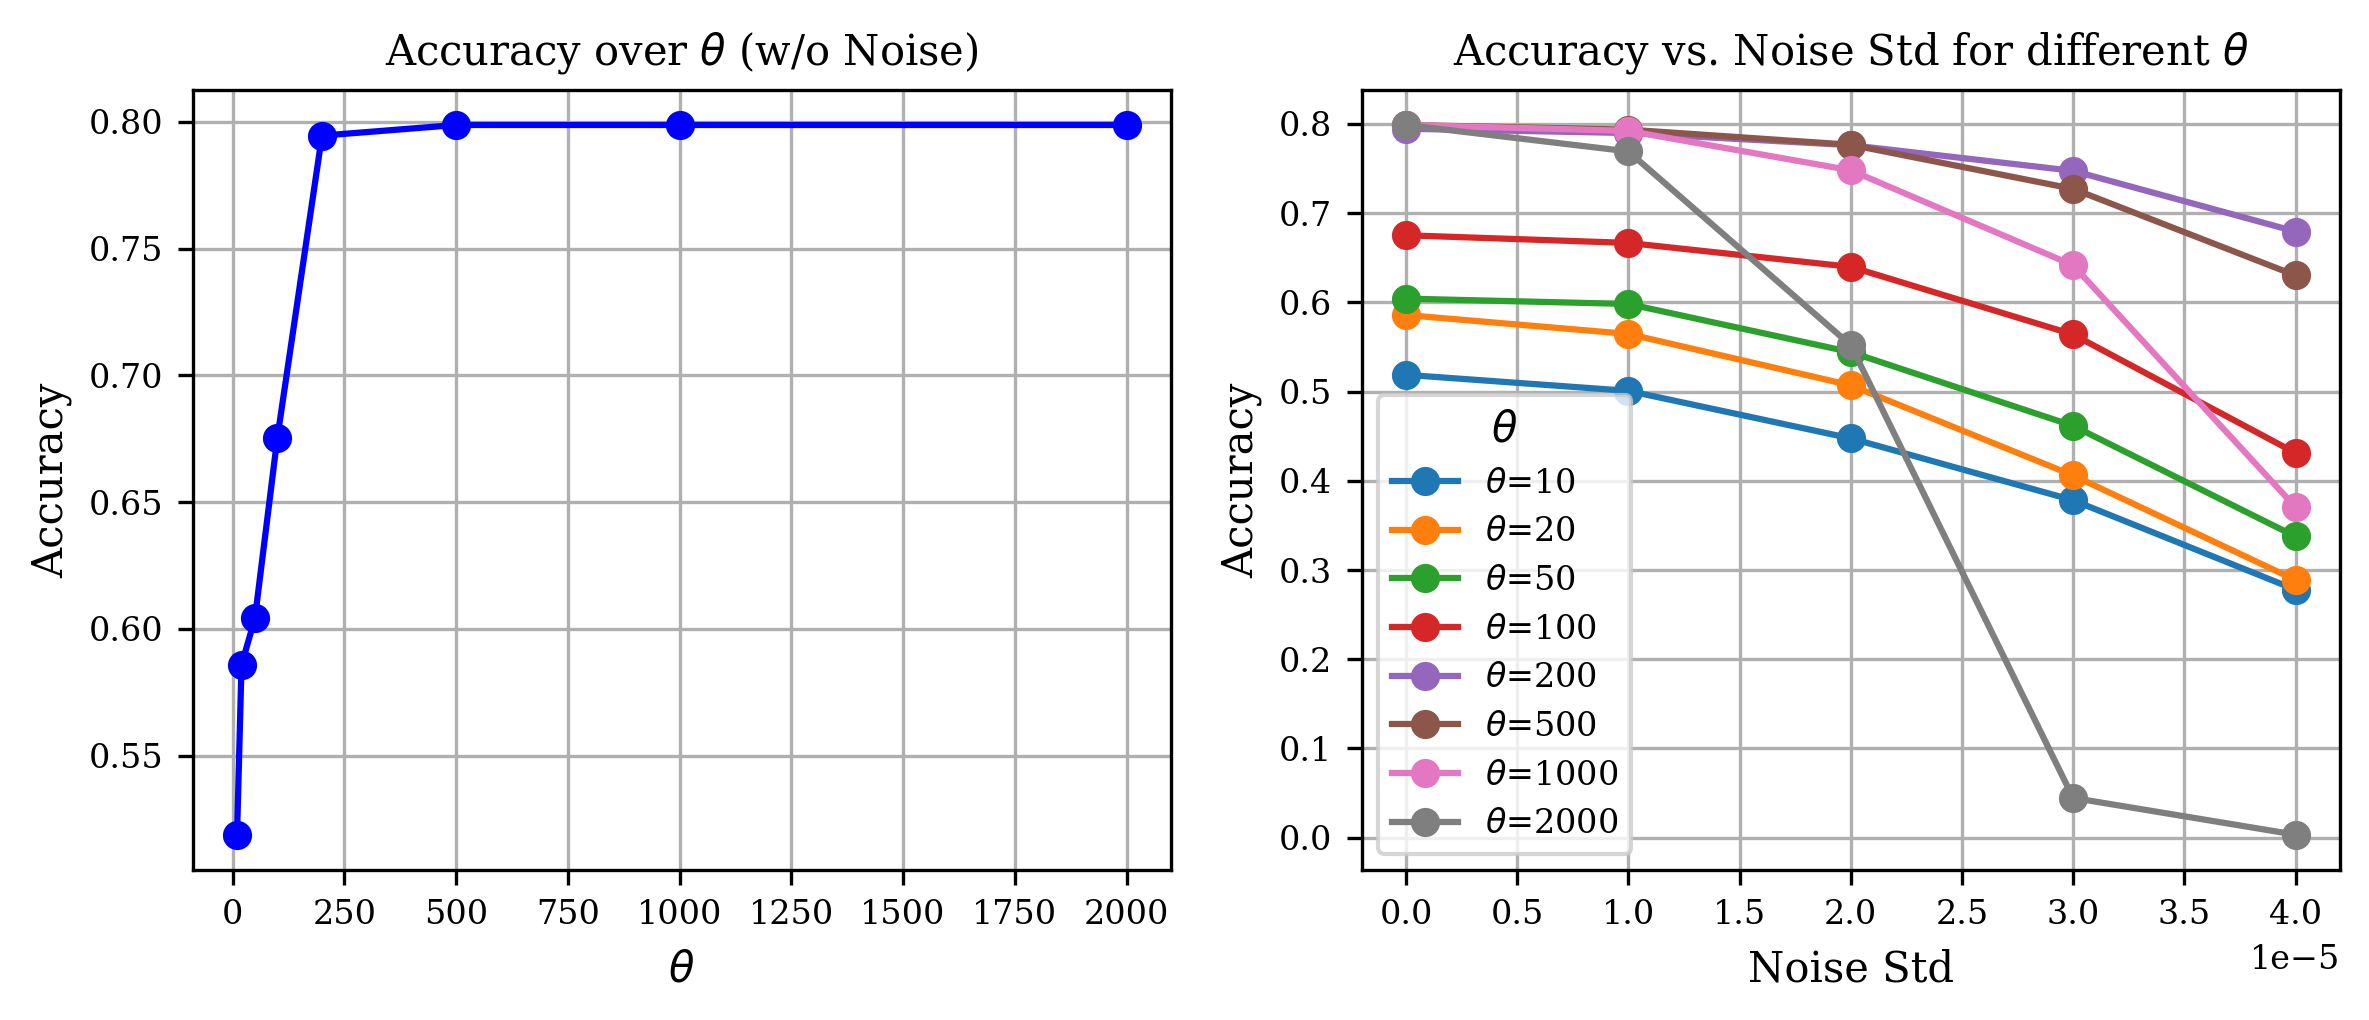

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv("wandb-theta-std.csv")

# 혹시 모를 타입 오류를 방지하기 위해 숫자형으로 변환
df['theta'] = pd.to_numeric(df['theta'], errors='coerce')
df['noise_std'] = pd.to_numeric(df['noise_std'], errors='coerce')
df['Final Accuracy'] = pd.to_numeric(df['Final Accuracy'], errors='coerce')

# 관련 열에 결측치가 있는 행 제거
df = df.dropna(subset=['theta', 'noise_std', 'Final Accuracy'])

# 1x2 형태의 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))

# --- 첫 번째 서브플롯 (왼쪽): noise_std == 0 일 때 theta에 따른 정확도 ---
df_zero_noise = df[df['noise_std'] == 0.0].sort_values(by='theta')
ax1.plot(df_zero_noise['theta'], df_zero_noise['Final Accuracy'], marker='o', linestyle='-', color='b')
ax1.set_title(f'Accuracy over Threshold $\\theta$ (w/o Noise)')
ax1.set_xlabel('$\\theta$')
ax1.set_ylabel('Accuracy')
ax1.grid(True)

# --- 두 번째 서브플롯 (오른쪽): theta별 noise_std에 따른 정확도 ---
thetas = df['theta'].unique()
for t in sorted(thetas):
    # 각 theta 값에 대해 noise_std를 기준으로 정렬
    df_t = df[df['theta'] == t].sort_values(by='noise_std')
    ax2.plot(df_t['noise_std'], df_t['Final Accuracy'], marker='o', linestyle='-', label=f'$\\theta$={t}')

ax2.set_title(f'Accuracy vs. Noise Std for different $\\theta$')
ax2.set_xlabel('Noise Std')
ax2.set_ylabel('Accuracy')
ax2.legend(title='$Threshold$')
ax2.grid(True)

plt.tight_layout()
plt.show()
# plt.savefig('accuracy_plot.png') # 이미지로 저장하려면 이 주석을 해제하세요.